## Forecast 2026/27 + Model comparison (table models)

Train on **league tables** through 2025/26, predict the **2026/27 table** for the confirmed squad.

Both models output a **full predicted table** (points + positions) — no match-by-match simulation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    predict_table,
    pl_2627_squad,
    STUDENT_T_NU,
    FORECAST_TRAIN_SEASONS,
)


In [2]:
matches = load_matches()
forecast_teams = pl_2627_squad(matches)
tables = load_season_tables(matches, FORECAST_TRAIN_SEASONS)

print(f"Forecast 2026/27: {len(forecast_teams)} teams")
for i, t in enumerate(forecast_teams, 1):
    print(f"  {i:2d}. {t}")


Forecast 2026/27: 20 teams
   1. Arsenal
   2. Aston Villa
   3. Bournemouth
   4. Brentford
   5. Brighton
   6. Chelsea
   7. Coventry
   8. Crystal Palace
   9. Everton
  10. Fulham
  11. Hull
  12. Ipswich
  13. Leeds
  14. Liverpool
  15. Man City
  16. Man United
  17. Newcastle
  18. Nott'm Forest
  19. Sunderland
  20. Tottenham


### Model 1 — static table model


In [3]:
stan1, team_to_idx, _, feature_stats1 = prepare_table_stan_static(
    tables, FORECAST_TRAIN_SEASONS
)
stan1["nu"] = STUDENT_T_NU
fit1 = CmdStanModel(stan_file="stan/table_static.stan").sample(
    data=stan1, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=1000, adapt_delta=0.99, show_progress=True,
)
print(fit1.diagnose())


15:03:45 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:03:48 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [4]:
feat1 = build_forecast_features(
    matches, "2526", forecast_teams, FORECAST_TRAIN_SEASONS, feature_stats1
)
pred1 = predict_table(
    fit1, forecast_teams, team_to_idx, model="static", team_features=feat1, n_sims=800, seed=1
)
pred1 = pred1.rename(columns={"pos_median": "pos_m1", "pts_median": "pts_m1"})
pred1.head(10)


,team,pos_m1,pos_mean,pts_m1,pts_mean
0,Man City,2.0,2.87875,76.524411,76.480664
1,Arsenal,2.5,3.23125,74.638451,74.438100
2,Man United,3.0,3.55250,72.336028,72.632601
3,Liverpool,6.0,6.81500,61.408768,61.662048
4,Tottenham,7.0,8.53875,57.204294,57.113750
5,Chelsea,8.0,8.51250,57.897780,57.448146
6,Aston Villa,10.0,10.88125,52.639499,51.774311
7,Bournemouth,11.0,10.89000,51.981318,51.512549
8,Newcastle,11.0,11.37875,49.963029,50.374958
9,Brighton,11.0,10.68750,52.001239,52.177725


### Model 2 — hierarchical table model (2526 skills)


In [5]:
stan2, team_to_idx2, _, season_to_idx, feature_stats2 = prepare_table_stan_hierarchical(
    tables, FORECAST_TRAIN_SEASONS
)
stan2["nu"] = STUDENT_T_NU
last_season_idx = season_to_idx["2526"]

fit2 = CmdStanModel(stan_file="stan/table_hierarchical.stan").sample(
    data=stan2, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1500, iter_sampling=1500, adapt_delta=0.99, show_progress=True,
)
print(fit2.diagnose())


15:03:53 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:04:00 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
feat2 = build_forecast_features(
    matches, "2526", forecast_teams, FORECAST_TRAIN_SEASONS, feature_stats2
)
pred2 = predict_table(
    fit2,
    forecast_teams,
    team_to_idx2,
    model="hierarchical",
    last_season_index=last_season_idx,
    team_features=feat2,
    n_sims=800,
    seed=2,
)
pred2 = pred2.rename(columns={"pos_median": "pos_m2", "pts_median": "pts_m2"})
pred2.head(10)


,team,pos_m2,pos_mean,pts_m2,pts_mean
0,Arsenal,2.0,2.63000,76.556546,76.486097
1,Man City,2.0,2.47625,76.782757,76.821754
2,Man United,3.0,3.25875,73.286380,73.179856
3,Liverpool,6.0,7.09125,60.588403,60.396407
4,Chelsea,8.0,9.03500,56.651750,56.353068
5,Tottenham,8.0,8.75875,56.575298,56.688529
6,Aston Villa,10.0,10.43125,53.554874,52.857078
7,Bournemouth,11.0,11.06000,51.909321,52.269544
8,Brighton,11.0,11.13250,51.869692,51.819577
9,Brentford,12.0,12.13500,50.129889,49.633238


### Side-by-side forecast 2026/27


In [7]:
comparison = pred1[["team","pos_m1","pts_m1"]].merge(
    pred2[["team","pos_m2","pts_m2"]], on="team"
)
comparison["pos_diff"] = comparison["pos_m1"] - comparison["pos_m2"]
comparison.sort_values("pos_m1")


,team,pos_m1,pts_m1,pos_m2,pts_m2,pos_diff
0,Man City,2.0,76.524411,2.0,76.782757,0.0
1,Arsenal,2.5,74.638451,2.0,76.556546,0.5
2,Man United,3.0,72.336028,3.0,73.286380,0.0
3,Liverpool,6.0,61.408768,6.0,60.588403,0.0
4,Tottenham,7.0,57.204294,8.0,56.575298,-1.0
5,Chelsea,8.0,57.897780,8.0,56.651750,0.0
6,Aston Villa,10.0,52.639499,10.0,53.554874,0.0
8,Newcastle,11.0,49.963029,12.0,50.503985,-1.0
9,Brighton,11.0,52.001239,11.0,51.869692,0.0
7,Bournemouth,11.0,51.981318,11.0,51.909321,0.0


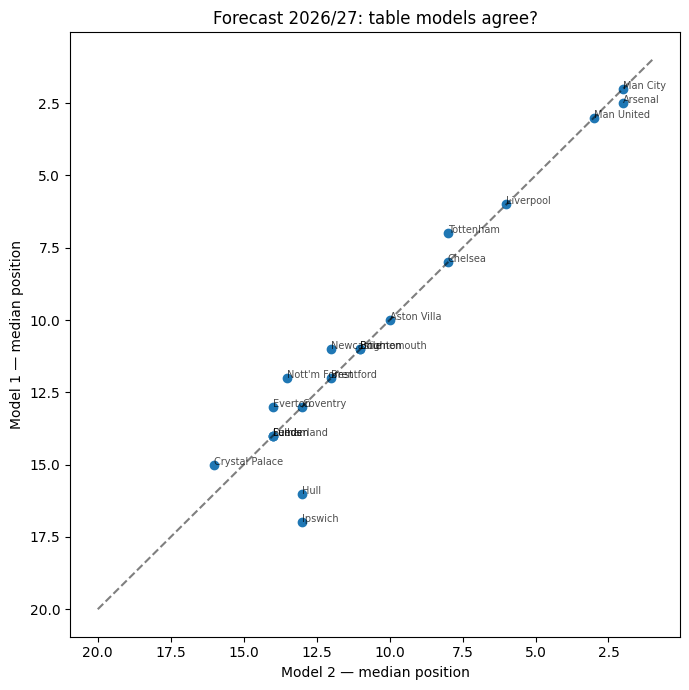

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comparison["pos_m2"], comparison["pos_m1"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_m2"], r["pos_m1"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Model 2 — median position")
ax.set_ylabel("Model 1 — median position")
ax.set_title("Forecast 2026/27: table models agree?")
ax.invert_xaxis(); ax.invert_yaxis()
plt.tight_layout(); plt.show()


### WAIC / LOO (team-season rows)


In [9]:
idata1 = az.from_cmdstanpy(fit1)
idata2 = az.from_cmdstanpy(fit2)
loo1, loo2 = az.loo(idata1), az.loo(idata2)
waic1, waic2 = az.waic(idata1), az.waic(idata2)

print("LOO Model 1:", loo1)
print("LOO Model 2:", loo2)
print(f"Delta ELPD (M2-M1): {loo2.elpd_loo - loo1.elpd_loo:.1f}")
print(az.compare({"M1 static table": idata1, "M2 hierarchical table": idata2}, ic="loo"))


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


LOO Model 1: Computed from 4000 posterior samples and 340 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1303.90    14.13
p_loo       36.76        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      340  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

LOO Model 2: Computed from 6000 posterior samples and 340 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1304.54    16.44
p_loo       73.23        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      340  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Delta ELPD (M2-M1): -0.6
                       rank     elpd_loo      p_loo  elpd_diff   weight  \
M1 static table           0 -1303.895708  36.757188   0.000000  0.60056   
M2 hierarchical table     1 -1304.535037  73.228154   0.639329  0.39944   

               

### Final assessment

- **Unit of prediction:** league **table** (points → rank), not single matches.
- **LOO** compares fit on historical **team-season points**; better ELPD ⇒ better table-level likelihood.
- For 2026/27, compare `pos_m1` vs `pos_m2`; large differences ⇒ report both forecasts.
